2025-03-20 09:18:39,425 - INFO - Loading spectral data...
2025-03-20 09:18:39,429 - INFO - Training the model...
2025-03-20 09:18:39,437 - INFO - Epoch 1/2000 - Validation Loss: 0.2349
2025-03-20 09:18:39,443 - INFO - Epoch 2/2000 - Validation Loss: 0.1240
2025-03-20 09:18:39,449 - INFO - Epoch 3/2000 - Validation Loss: 0.0997


2025-03-20 09:18:39,459 - INFO - Epoch 4/2000 - Validation Loss: 0.0799
2025-03-20 09:18:39,464 - INFO - Epoch 5/2000 - Validation Loss: 0.0719
2025-03-20 09:18:39,470 - INFO - Epoch 6/2000 - Validation Loss: 0.0602
2025-03-20 09:18:39,476 - INFO - Epoch 7/2000 - Validation Loss: 0.0533
2025-03-20 09:18:39,484 - INFO - Epoch 8/2000 - Validation Loss: 0.0483
2025-03-20 09:18:39,490 - INFO - Epoch 9/2000 - Validation Loss: 0.0415
2025-03-20 09:18:39,496 - INFO - Epoch 10/2000 - Validation Loss: 0.0393
2025-03-20 09:18:39,501 - INFO - Epoch 11/2000 - Validation Loss: 0.0357
2025-03-20 09:18:39,508 - INFO - Epoch 12/2000 - Validation Loss: 0.0355
2025-03-20 09:18:39,513 - INFO - Epoch 13/2000 - Validation Loss: 0.0368
2025-03-20 09:18:39,519 - INFO - Epoch 14/2000 - Validation Loss: 0.0385
2025-03-20 09:18:39,525 - INFO - Epoch 15/2000 - Validation Loss: 0.0333
2025-03-20 09:18:39,532 - INFO - Epoch 16/2000 - Validation Loss: 0.0338
2025-03-20 09:18:39,539 - INFO - Epoch 17/2000 - Validati

Early stopping triggered after 50 epochs with no improvement.


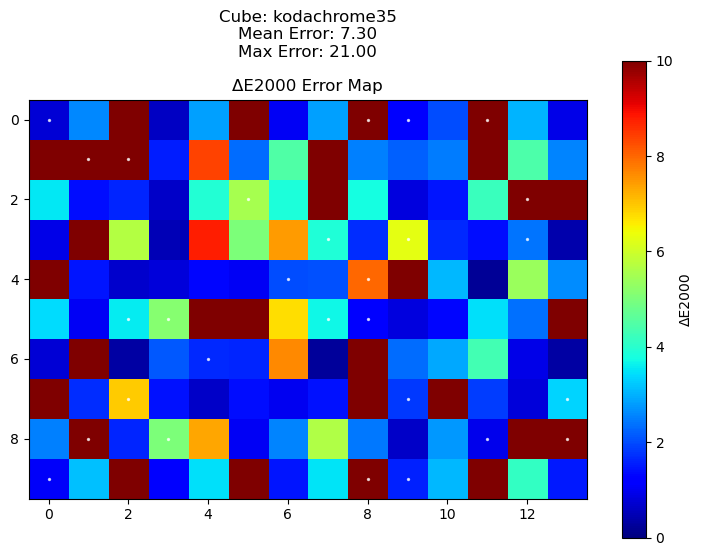

In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os
import copy

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Fix seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# 1. Load Spectral Data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_kodachrome35.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref = np.array(cube_ref.metadata['wavelength'], dtype=float)

# Ensure input and reference have different band sizes
H, W, bd_input = cube_data.shape
_, _, bd_ref = cube_ref_data.shape
spectral_input = cube_data.reshape(-1, bd_input)
spectral_ref = cube_ref_data.reshape(-1, bd_ref)

###########################################
# 2. Normalize spectral data
###########################################
scaler_input = StandardScaler()
scaler_ref = StandardScaler()
X_norm = scaler_input.fit_transform(spectral_input)
Y_norm = scaler_ref.fit_transform(spectral_ref)

X_full = X_norm.reshape(cube_data.shape)
Y_full = Y_norm.reshape(cube_ref_data.shape)

# Flatten the data
X_flat = X_full.reshape(-1, bd_input)
Y_flat = Y_full.reshape(-1, bd_ref)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)  # 80% for training
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

# Split data
X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# 3. Define Neural Network
###########################################
class SpectralMLP(nn.Module):
    def __init__(self, input_bands, output_bands, hidden_size=128):
        super(SpectralMLP, self).__init__()
        self.fc1 = nn.Linear(input_bands, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_bands)
    
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))
    
class EarlyStopping:
    def __init__(self, patience=10, delta=0, verbose=False, path='best_model.pth'):
        self.patience = patience  # Number of epochs to wait for improvement
        self.delta = delta  # Minimum change to qualify as an improvement
        self.verbose = verbose  # Whether to print the stop message
        self.path = path  # Path to save the best model
        self.best_loss = None  # Best validation loss
        self.counter = 0  # Counter for how many epochs without improvement
        self.early_stop = False  # Flag to stop the training
        self.best_model_wts = None  # To store the best model's weights

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0  # Reset the counter
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"Early stopping triggered after {self.counter} epochs with no improvement.")
                    
        return self.early_stop
    
# Hybrid Angular Loss Function
class HybridAngularLoss(nn.Module):
    def __init__(self, alpha=0.5):
        super(HybridAngularLoss, self).__init__()
        self.alpha = alpha
        self.mse_loss = nn.MSELoss()

    def forward(self, pred, target):
        # MSE Loss
        mse_loss = self.mse_loss(pred, target)

        # Angular loss (cosine similarity)
        pred_normalized = pred / (torch.norm(pred, dim=1, keepdim=True) + 1e-8)
        target_normalized = target / (torch.norm(target, dim=1, keepdim=True) + 1e-8)

        cosine_similarity = torch.sum(pred_normalized * target_normalized, dim=1)
        angular_loss = 1 - cosine_similarity  # Angular loss (1 - cosine similarity)

        # Hybrid loss: MSE + Angular loss
        return self.alpha * mse_loss + (1 - self.alpha) * torch.mean(angular_loss)


model = SpectralMLP(input_bands=bd_input, output_bands=bd_ref)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
loss_function = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=300, gamma=0.5)  # Reduce LR every 200 epochs
early_stopping = EarlyStopping(patience= 50, delta = 0, verbose=True)



###########################################
# 4. Train the Model
###########################################
epochs = 2000
batch_size = 8
val_losses = []


logging.info('Training the model...')
for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]
    epoch_train_loss = 0.0
    
    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]
        
        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
   
    
    scheduler.step()  # Reduce learning rate
    model.eval()
    with torch.no_grad():
        Y_val_pred = model(X_test_torch)
        val_loss = loss_function(Y_val_pred, Y_test_torch).item()
    val_losses.append(val_loss)
    logging.info(f'Epoch {epoch+1}/{epochs} - Validation Loss: {val_loss:.4f}')

    # Check for early stopping
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        logging.info("Early stopping triggered.")
        break

model.load_state_dict(early_stopping.best_model_wts)
 
###########################################
# 5. Apply Correction and Convert to Lab
###########################################
logging.info('Applying correction to full image...')
corrected_spectral = model(torch.tensor(X_norm, dtype=torch.float32)).detach().numpy()
corrected_spectral = scaler_ref.inverse_transform(corrected_spectral)
corrected_spectral_image = corrected_spectral.reshape(H, W, bd_ref)

# Extract the wavelengths from CMFs and the input spectral bands
cmf_wavelengths = CMFs[:, 0]  # Wavelengths in CMF data
corrected_wavelengths = wl_ref  # Wavelengths in the corrected spectral image (36 values)

# Interpolate CMFs to match the 36 bands
interpolated_cmfs = np.column_stack([
    np.interp(corrected_wavelengths, cmf_wavelengths, CMFs[:, 1]),
    np.interp(corrected_wavelengths, cmf_wavelengths, CMFs[:, 2]),
    np.interp(corrected_wavelengths, cmf_wavelengths, CMFs[:, 3])
])

xyz_corrected = np.dot(corrected_spectral_image, interpolated_cmfs)
xyz_corrected /= np.sum(interpolated_cmfs[:, 1], axis=0)

# Convert XYZ to Lab and compute ΔE2000
lab_corrected = color.xyz2lab(xyz_corrected)
xyz_ref = np.dot(cube_ref_data, interpolated_cmfs)
xyz_ref /= np.sum(interpolated_cmfs[:, 1], axis=0)
lab_ref = color.xyz2lab(xyz_ref)
error_map = color.deltaE_ciede2000(lab_ref, lab_corrected)

# Compute Mean ΔE2000
error_map_flat = error_map.reshape(-1)
# Extract only test-set errors using precomputed test_indices
test_error_values = error_map_flat[test_indices]
# Compute mean & max ΔE2000 error for the test set
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)

# Get train set pixel positions in the image
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot the ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')

# Add text annotations for Mean and Max Error and File name
file_name = os.path.splitext(os.path.basename(cube_path))[0]
file_name = file_name.split('_', 1)[-1]

plt.text(0.5, 1.1, f'Cube: {file_name}\nMean Error: {mean_error_test:.2f}\nMax Error: {max_error_test:.2f}', 
         ha='center', va='bottom', transform=plt.gca().transAxes, fontsize=12, color='black')

# Adjust layout to ensure the annotations are visible
plt.tight_layout(pad=3.0)
plt.show()


